### Import Data

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập cấu hình hiển thị
plt.style.use('seaborn-v0_8')
%matplotlib inline

# categories, products, clicks, views, purchases, queries

categories = pd.read_csv('/Users/macbook/Documents/Kì 2 Năm 3/Project Siêu To/Kaglle/product-categories.csv', sep=';') #2mb, thiếu biến productCategoryID (serial) 
products = pd.read_csv('/Users/macbook/Documents/Kì 2 Năm 3/Project Siêu To/Kaglle/products.csv', sep=';') # 7.3mb, thiếu biến imageName (name of the corresponding product image) tại chưa cần
clicks = pd.read_csv('/Users/macbook/Documents/Kì 2 Năm 3/Project Siêu To/Kaglle/train-clicks.csv', sep=';') #22.5mb, file này bản gốc không có
views = pd.read_csv('/Users/macbook/Documents/Kì 2 Năm 3/Project Siêu To/Kaglle/train-item-views.csv', sep=';') # 42.7mb, file này đủ
purchases = pd.read_csv('/Users/macbook/Documents/Kì 2 Năm 3/Project Siêu To/Kaglle/train-purchases.csv', sep=';') #750kb, file này có thêm biến userID
queries = pd.read_csv('/Users/macbook/Documents/Kì 2 Năm 3/Project Siêu To/Kaglle/train-queries.csv', sep=';') # 860mb, file này thiếu regionID

/var/folders/dm/fk87zbb17nzb594pksfvrc4c0000gn/T/ipykernel_2078/870096548.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  queries = pd.read_csv('/Users/macbook/Documents/Kì 2 Năm 3/Project Siêu To/Kaglle/train-queries.csv', sep=';') # 860mb


In [81]:
files = {
    'products': products,
    'categories': categories,
    'views': views,
    'clicks': clicks,
    'purchases': purchases,
    'queries': queries
}

In [51]:
from datetime import timedelta

## **docs/data_contract.md**

### Tổng quan các biến trong bộ dữ liệu

| Tên tệp tin | Các trường dữ liệu (Fields) | Vai trò trong mô hình hóa |
| :--- | :--- | :--- |
| `products.csv` | `itemId`, `pricelog2`, `product.name.tokens`| Chứa danh sách các món đồ, giá cả (đã được lấy log) và tên đã được mã hóa. |
| `product-categories.csv` | `itemId`, `categoryID` | Cho biết món đồ đó thuộc nhóm nào (ví dụ: áo sơ mi thuộc nhóm thời trang nam). |
| `train-item-views.csv` | `sessionId`	`userId`	`itemId`	`timeframe`	`eventdate` | Ghi lại việc khách hàng nhấp vào xem một món đồ nhưng chưa chắc đã mua.|
| `train-clicks.csv` | `queryId`, `timeframe`, `itemId` | Chứa các tương tác nhấp chuột từ trang kết quả tìm kiếm. `timeframe` (mili giây tính từ sự kiện đầu phiên)|
| **`train-purchases.csv`** |`sessionId`	`userId`	`timeframe`	`eventdate`	`ordernumber`	`itemId` | Ghi lại các giao dịch thành công. Đây là "đích đến" mà mọi mô hình AI cần dự đoán. File này quan trọng nhất|
| `train-queries.pbz2` | `queryId`	`sessionId`	`userId`	`timeframe`	`duration`	`eventdate`	`searchstring.tokens`	`categoryId`	`items`	`is.test` | Ghi lại các từ khóa khách hàng đã gõ vào ô tìm kiếm. |

### Phân tích Từng Biến

| Tên biến | Đơn vị | Giải thích ý nghĩa |
| :--- | :----- | :--- |
| `userId` | int | Mã định danh người dùng duy nhất đã được ẩn danh hóa. |
| `itemId` | int | Mã số định danh duy nhất cho mỗi sản phẩm trong hệ thống. 139578, 417975, 291805... |
| `sessionId` | int | Mã định danh cho một phiên làm việc, giới hạn bởi 1 giờ người dùng không hoạt động. Nếu bạn vào web lúc 8h sáng, xem vài món rồi thoát ra, đó là 1 Session. Nếu 3 tiếng sau bạn quay lại, hệ thống sẽ tính là Session mới. |
| `queryId` | int | Mỗi lần bạn gõ vào ô tìm kiếm và nhấn Enter, hệ thống tạo ra một mã số định danh cho lần tìm kiếm đó. |
| `pricelog2` | float | $\log_2(\text{Giá} + 1)$ Giá sản phẩm đã được chuẩn hóa theo thang logarit cơ số 2 để xử lý các giá trị cực biên. |
| `product.name.tokens` | int | Tên sản phẩm đã được cắt ra từng từ và thay bằng số. Ví dụ: "Giày" = 5, "Chạy" = 12, "Bộ" = 7. Bạn sẽ thấy một dãy số như [5, 12, 7]. |
| `categoryID` / `categoryId` | int | Mã định danh danh mục sản phẩm, dùng để phân loại hàng hóa. 1096, 527... |
| `timeframe` | int | Đây là "đồng hồ bấm giờ" tính bằng mili giây. Khi Session bắt đầu, nó là 0. Nếu 10 giây sau bạn click vào ảnh, timeframe sẽ ghi là 10,000ms. Nó cho biết tốc độ đưa ra quyết định của khách hàng. |
| `duration` | int | Tổng thời gian bạn dừng lại ở trang kết quả tìm kiếm đó. Ở lại càng lâu chứng tỏ bạn đang cân nhắc kỹ hoặc nội dung đó hấp dẫn. Mili giây |
| `eventdate` | date | Ngày diễn ra sự kiện. Dùng để phân tích thói quen mua sắm theo ngày trong tuần hoặc mùa lễ hội. |
| `searchstring.tokens` | int | Tương tự tên sản phẩm, đây là các từ khóa bạn gõ vào ô tìm kiếm đã được chuyển thành số. |
| `items` | int | Khi bạn tìm "Giày", hệ thống hiện ra 10 sản phẩm. Danh sách 10 cái itemId đó chính là biến này. |
| `ordernumber` | int | Nếu bạn thanh toán thành công, hệ thống cấp một mã hóa đơn. Nếu biến này trống (null), nghĩa là khách mới chỉ xem chứ chưa mua. |
| `is.test` | int | Biến phân loại dùng để đánh dấu bản ghi thuộc tập dữ liệu huấn luyện hay kiểm thử. |


| Nhóm chức năng | Tên biến | Đơn vị | Ý nghĩa thực tế |
| :--- | :--- | :--- | :--- |
| **1. Định danh (Identity)** | `userId`, `sessionId`, `itemId`, `queryId` | int | Dùng để kết nối các hành vi của cùng một người hoặc cùng một sản phẩm lại với nhau. |
| **2. Đặc trưng sản phẩm (Content)** | `pricelog2`, `product.name.tokens`, `categoryID` | float / int / int | Mô tả "bản chất" của món hàng. Log-scale giúp máy không bị sốc bởi giá quá cao hoặc quá thấp. |
| **3. Bối cảnh & Thời gian (Context)** | `timeframe`, `eventdate`, `duration` | ms / Date | Cho biết khách hàng đang vội hay đang thong thả, và họ thao tác vào thời điểm nào trong ngày. |
| **4. Hành vi tìm kiếm (Search)** | `searchstring.tokens`, `items` | Tokens / List IDs | Thể hiện ý định của người dùng qua từ khóa và những gì hệ thống đã hiển thị cho họ thấy. |
| **5. Kết quả & Phân loại (Target)** | `ordernumber`, `is.test` | ID / Boolean | `ordernumber` cho biết giao dịch có chốt đơn thành công hay không. `is.test` dùng để chia tập dữ liệu. |

### Định nghĩa các loại tương tác

Trong Diginetica, hành vi người dùng được chia thành các cấp độ từ "tìm kiếm" đến "mua hàng":

- Queries (train-queries.pbz2): Là hành động Tìm kiếm. Người dùng gõ từ khóa (searchstring.tokens) hoặc nhấn vào một danh mục (categoryId). Hệ thống trả về một trang kết quả (SERP) chứa danh sách các sản phẩm (items). 

- Clicks (train-clicks.csv): Là hành động Nhấp chuột từ trang kết quả SERP. Khi người dùng thấy danh sách sản phẩm sau khi tìm kiếm (Query), họ nhấp vào một sản phẩm cụ thể. Do đó, tệp này luôn đi kèm queryId. 

- Views (train-item-views.csv): Là hành động Xem chi tiết sản phẩm. Đây là khi người dùng thực sự vào trang mô tả của món đồ. Lưu ý: Dữ liệu này thường được lấy mẫu (sampled), nên có trường hợp khách click vào sản phẩm nhưng bản ghi view không được ghi nhận. 

- Purchases (train-purchases.csv): Là hành động Mua hàng. Đây là tương tác giá trị nhất, xác nhận một giao dịch thành công với mã hóa đơn ordernumber.

### Mối quan hệ giữa các tệp dữ liệu

Các tệp này không đứng độc lập mà kết nối với nhau qua các "khóa" (Keys) để tạo thành một chuỗi hành trình khách hàng:

- Mối quan hệ Clicks - Queries: Tệp train-clicks.csv của bạn không có sessionId. Để biết cú Click đó thuộc về phiên làm việc nào, bạn phải Join nó với tệp train-queries.pbz2 thông qua queryId. 

- Mối quan hệ Session - Interactions: sessionId là sợi dây liên kết giữa Queries, Views và Purchases. Một phiên làm việc (Session) bao gồm tất cả các hành động này diễn ra liên tục (ngắt quãng không quá 1 giờ). 

- Mối quan hệ Item - Metadata: Tất cả các tệp tương tác đều chứa itemId, cho phép bạn truy vấn ngược lại giá (pricelog2) trong products.csv hoặc danh mục trong product-categories.csv.

### Giải thích biến Timeframe

user queries ra được một đống items, click vào item, view item, purchase

## **Notebooks/01_eda_diginetica.ipynb**

### ĐỌC DỮ LIỆU THÔ & KIỂM TRA TỔNG QUAN

In [35]:
print(f"Tổng số Products: {len(products)}")
print(f"Tổng số Product Categories: {len(categories)}") # 1 danh mục chứa nhiều sản phẩm
print(f"Tổng số Clicks: {len(clicks)}")
print(f"Tổng số Views: {len(views)}")
print(f"Tổng số Purchases: {len(purchases)}")
print(f"Tổng số Queries: {len(queries)}")

Tổng số Products: 184047
Tổng số Product Categories: 184047
Tổng số Clicks: 1127764
Tổng số Views: 1235380
Tổng số Purchases: 18025
Tổng số Queries: 923127


In [55]:
print(f"Số lượng bản ghi Views: {len(views)}")
print(f"Số lượng sessionId duy nhất: {views['sessionId'].nunique()}")
print(f"Số lượng itemId duy nhất: {products['itemId'].nunique()}")
print(f"Khoảng thời gian: {views['eventdate'].min()} đến {views['eventdate'].max()}")

Số lượng bản ghi Views: 1235380
Số lượng sessionId duy nhất: 310324
Số lượng itemId duy nhất: 184047
Khoảng thời gian: 2016-01-01 đến 2016-06-01


In [57]:
import pandas as pd

# 1. Đếm tổng số khách hàng duy nhất trên toàn bộ hệ thống (Bảng Views thường đầy đủ nhất)
total_users = views['userId'].nunique()
print(f"Tổng số khách hàng duy nhất: {total_users:,}")

# 2. Đếm số khách hàng đã thực hiện hành vi mua hàng
buyers = purchases['userId'].nunique()
print(f"Số lượng khách hàng đã mua hàng: {buyers:,}")

# 3. Tính tỷ lệ khách hàng chuyển đổi (Conversion Rate theo User)
conversion_rate = (buyers / total_users) * 100
print(f"Tỷ lệ khách hàng có chốt đơn: {conversion_rate:.2f}%")

Tổng số khách hàng duy nhất: 87,934
Số lượng khách hàng đã mua hàng: 4,425
Tỷ lệ khách hàng có chốt đơn: 5.03%


### Missing Values và Skewness

In [82]:
def inspect_dataset(df_name, df):
    print(f"\n=== INSPECTING: {df_name.upper()} ===")
    
    # 1. Kiểm tra Missing Values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    
    # 2. Kiểm tra Skewness cho các biến số (Numeric) [3]
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    skew_vals = df[numeric_cols].skew()
    
    # Tổng hợp kết quả
    info = pd.DataFrame({
        'Dtype': df.dtypes,
        'Missing': missing,
        'Missing %': missing_pct.round(2),
        'Unique Values': df.nunique(),
        'Skewness': skew_vals.round(2)
    })
    
    print(info)
    
    # Giải thích độ lệch (Skewness):
    # Skew > 0: Lệch phải (đuôi dài bên phải) - Phổ biến trong TMĐT như giá cả, số lượt xem
    # Skew < 0: Lệch trái
    # Skew ~ 0: Phân bổ chuẩn (Symmetrical)

for name, df in files.items():
    inspect_dataset(name, df)


=== INSPECTING: PRODUCTS ===
                      Dtype  Missing  Missing %  Unique Values  Skewness
itemId                int64        0        0.0         184047      0.62
pricelog2             int64        0        0.0             13     -0.50
product.name.tokens  object        0        0.0         182392       NaN

=== INSPECTING: CATEGORIES ===
            Dtype  Missing  Missing %  Unique Values  Skewness
itemId      int64        0        0.0         184047      0.62
categoryId  int64        0        0.0           1217      0.05

=== INSPECTING: VIEWS ===
                    Dtype  Missing  Missing %  Unique Values  Skewness
eventdate  datetime64[ns]        0       0.00            152       NaN
itemId              int64        0       0.00         122993      1.91
sessionId           int64        0       0.00         310324      0.46
timeframe           int64        0       0.00         644845      0.95
userId            float64   862389      69.81          87934      0.67

===

Missing Values: Trong Diginetica, userId thường bị thiếu rất nhiều (NaN) vì nhiều khách hàng duyệt web ẩn danh. Không nên xóa bỏ các hàng này mà hãy xử lý chúng như người dùng ẩn danh.

Skewness (Độ lệch):

- timeframe và duration thường có Skewness > 1 (lệch phải rất mạnh). Điều này có nghĩa là đại đa số người dùng thoát rất nhanh, chỉ một số ít ở lại rất lâu.

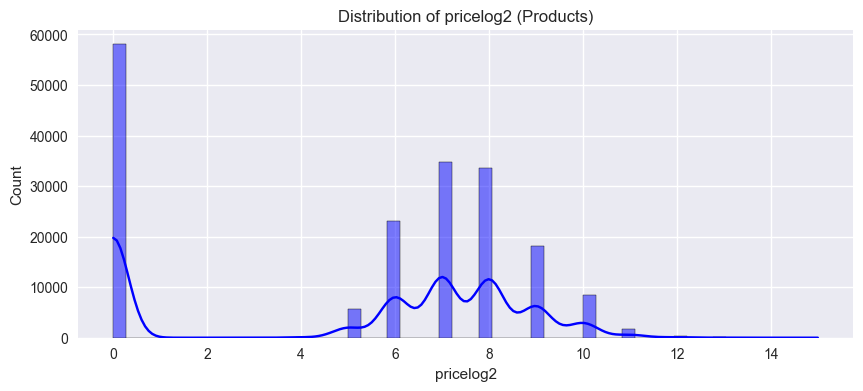

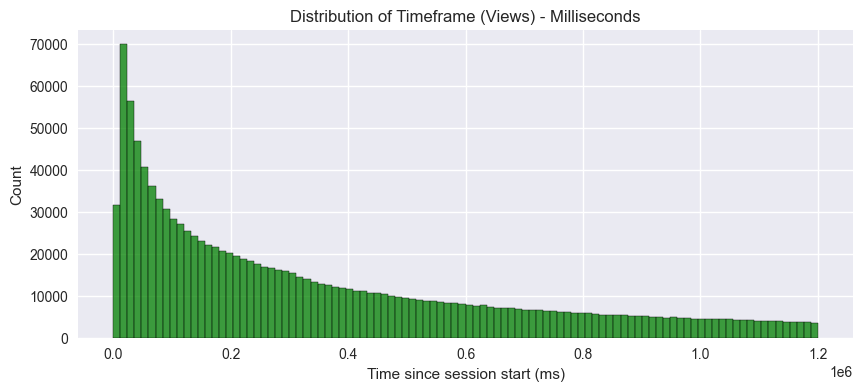

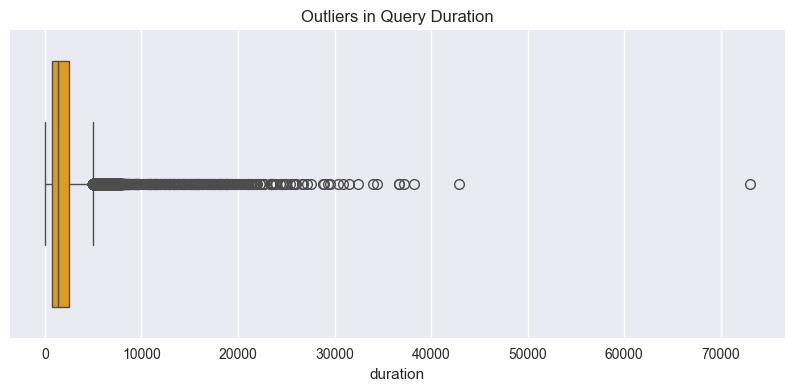

In [83]:
# 1. Phân bổ giá (pricelog2) - Thường có độ lệch thấp do đã lấy Log [4, 5]
plt.figure(figsize=(10, 4))
sns.histplot(files['products']['pricelog2'], kde=True, color='blue')
plt.title('Distribution of pricelog2 (Products)')
plt.show()

# 2. Phân bổ timeframe trong Views - Thường lệch phải cực nặng do session dài [6]
plt.figure(figsize=(10, 4))
sns.histplot(files['views']['timeframe'], bins=100, color='green')
plt.title('Distribution of Timeframe (Views) - Milliseconds')
plt.xlabel('Time since session start (ms)')
plt.show()

# 3. Phân bổ thời gian thực hiện Query (duration) [4]
plt.figure(figsize=(10, 4))
sns.boxplot(x=files['queries']['duration'], color='orange')
plt.title('Outliers in Query Duration')
plt.show()

In [84]:
# Kiểm tra xem có bao nhiêu itemId trong Views không tồn tại trong danh mục Products [7]
view_items = set(files['views']['itemId'])
prod_items = set(files['products']['itemId'])

leaked_items = view_items - prod_items
print(f"Số lượng itemId trong Views nhưng KHÔNG có trong Products: {len(leaked_items)}")

# Kiểm tra sự mất cân bằng giữa Click và Purchase
print(f"Tỷ lệ bản ghi Purchase so với View: {(len(files['purchases'])/len(files['views'])*100):.2f}%")

Số lượng itemId trong Views nhưng KHÔNG có trong Products: 0
Tỷ lệ bản ghi Purchase so với View: 1.46%


### PHÂN TÍCH SESSION LENGTH

Median: 3.0, P90: 9.0, P95: 12.0


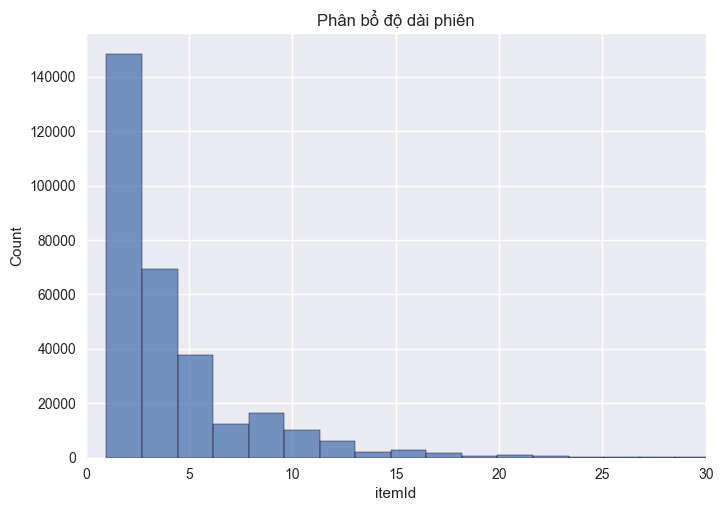

In [58]:
# Độ dài phiên dựa trên số lượng tương tác
session_lengths = views.groupby('sessionId')['itemId'].count()
stats = session_lengths.describe(percentiles=[.5,.9,.95])
print(f"Median: {stats['50%']}, P90: {stats['90%']}, P95: {stats['95%']}")

# Vẽ biểu đồ
sns.histplot(session_lengths, bins=50)
plt.xlim(0, 30) # Cắt ngưỡng visualization
plt.title('Phân bổ độ dài phiên')
plt.show()
# Rule đề xuất: Cắt bỏ các phiên chỉ có 1 hành động (không thể dự đoán next-item) [2, 6]

phân tích bảng: Độ dài của một phiên làm việc" (Session Length) – tức là một khách hàng xem bao nhiêu sản phẩm trước khi họ rời đi hoặc chốt đơn.

itemId ở đây là số lượng sản phẩm được tương tác trong một phiên. Đại diện cho độ dài của 1 phiên

count ở đây là Số lượng phiên (Session) có độ dài tương ứng.

1. Phân tích các con số thống kê
Median (Trung vị) = 3.0: Đây là con số quan trọng nhất. Nó cho biết 50% số phiên trong dữ liệu chỉ có từ 3 hành động trở xuống. Khách hàng lướt khá nhanh.

- P90 = 9.0: 90% số phiên có độ dài từ 9 hành động trở xuống.

- P95 = 12.0: Chỉ có 5% khách hàng kiên nhẫn xem trên 12 sản phẩm trong một phiên.

2. Hình dáng biểu đồ (Histogram)
- Biểu đồ bị "lệch phải" (Right-skewed) cực mạnh. Cột cao nhất nằm ở sát mốc 1-2 hành động.

- Điều này cho thấy đa số người dùng vào "ngó" một cái rồi ra ngay (Bounce).

- Đuôi của biểu đồ kéo dài nhưng rất thấp: Có một số ít người dùng cực kỳ tích cực (xem hơn 20-30 món), nhưng đây là trường hợp ngoại lệ (outliers).

### PHÂN TÍCH ITEM POPULARITY (LONG-TAIL)

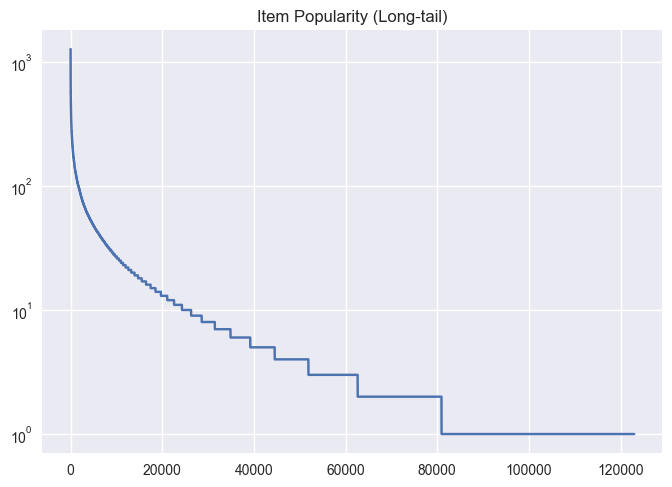

In [59]:
item_counts = views['itemId'].value_counts()
plt.plot(range(len(item_counts)), item_counts.values)
plt.yscale('log')
plt.title('Item Popularity (Long-tail)')
plt.show()

- Trục hoành (Trục ngang): Thứ hạng của sản phẩm (từ 0 đến hơn 120,000). Sản phẩm ở vị trí số 0 là sản phẩm được xem nhiều nhất, sản phẩm ở vị trí 120,000 là sản phẩm ít người xem nhất.

- Trục tung (Trục đứng - thang Logarit): Số lượt xem (count). Lưu ý trục này dùng thang 10^0, 10^1, 10^2, 10^3, nghĩa là khoảng cách giữa các vạch là gấp 10 lần nhau. Điều này giúp chúng ta nhìn rõ độ dốc cao khủng khiếp của dữ liệu.


- Phần đầu (Short Head): Một số rất ít sản phẩm (khoảng vài nghìn cái đầu tiên) chiếm đại đa số lượt xem. Đây là những sản phẩm "quốc dân", cực kỳ phổ biến.

- Phần đuôi (Long Tail): Chiếm phần lớn chiều dài trục ngang (từ vị trí 20,000 đến 120,000). Đây là hàng trăm nghìn sản phẩm "ngách", mỗi sản phẩm chỉ có 1 hoặc 2 lượt xem trong suốt cả tháng.

- Vấn đề "Popularity Bias": Nếu bạn dùng thuật toán đơn giản, máy sẽ luôn gợi ý những món ở "Phần đầu" vì dữ liệu về chúng quá nhiều. Điều này khiến khách hàng cảm thấy chán vì đi đâu cũng thấy gợi ý giống nhau.
- Thử thách "Cold Start" cho sản phẩm ngách: Những sản phẩm ở "Phần đuôi" có quá ít dữ liệu (chỉ 1-2 lượt xem). Máy sẽ không biết phải gợi ý chúng cho ai. Tuy nhiên, tổng doanh thu từ hàng trăm nghìn món ở "Phần đuôi" này đôi khi lại lớn hơn cả "Phần đầu".
- Lọc nhiễu: Ở cuối biểu đồ (khoảng từ sản phẩm thứ 80,000 trở đi), đường kẻ đi ngang ở mức $10^0 = 1$. Có rất nhiều sản phẩm chỉ được xem đúng 1 lần. Rất nên cân nhắc lọc bỏ những sản phẩm này khi huấn luyện mô hình để giảm dung lượng bộ nhớ mà không làm giảm độ chính xác của mô hình.

In [70]:
import pandas as pd

def analyze_pareto_popularity(df, item_col='itemId'):
    # 1. Đếm số lượt xem cho mỗi sản phẩm và sắp xếp giảm dần
    item_counts = df[item_col].value_counts().sort_values(ascending=False)
    
    # 2. Tính tổng số lượt xem và tổng số sản phẩm duy nhất
    total_views = item_counts.sum()
    total_items = len(item_counts)
    
    # 3. Tính phần trăm tích lũy của lượt xem
    cum_views_pct = (item_counts.cumsum() / total_views) * 100
    
    # 4. Tìm giá trị tại mốc 20% số lượng sản phẩm
    top_20_percent_idx = int(0.2 * total_items)
    views_at_20_pct_items = cum_views_pct.iloc[top_20_percent_idx]
    
    # 5. Tìm xem bao nhiêu % sản phẩm thì chiếm được 80% lượt xem
    items_at_80_pct_views = (cum_views_pct <= 80).sum()
    items_pct_for_80_views = (items_at_80_pct_views / total_items) * 100
    
    # Trình bày kết quả
    print(f"--- PHÂN TÍCH PARETO (80/20) ---")
    print(f"1. Top 20% sản phẩm ({top_20_percent_idx:,} món) chiếm: {views_at_20_pct_items:.2f}% tổng lượt xem.")
    print(f"2. Để đạt 80% tổng lượt xem, chỉ cần: {items_pct_for_80_views:.2f}% số lượng sản phẩm.")
    
    return {
        "total_items": total_items,
        "top_20_pct_views": views_at_20_pct_items,
        "items_pct_for_80_views": items_pct_for_80_views
    }

# Chạy thử với bảng views
result = analyze_pareto_popularity(views)

--- PHÂN TÍCH PARETO (80/20) ---
1. Top 20% sản phẩm (24,598 món) chiếm: 77.54% tổng lượt xem.
2. Để đạt 80% tổng lượt xem, chỉ cần: 22.59% số lượng sản phẩm.


- 77.54% tổng lượt xem tập trung vào 24,598 món: Điều này xác nhận hệ thống có một nhóm "ngôi sao" (Star products) rất mạnh. Khoảng 24k sản phẩm này là động lực chính kéo lưu lượng (traffic) cho website.

- 22.59% sản phẩm gánh 80% lượt xem: Chỉ cần tập trung tối ưu cho hơn 1/5 danh mục hàng hóa là đã phục vụ tốt cho 80% nhu cầu tìm kiếm của khách hàng.

### SPARSITY

In [60]:
n_sessions = views['sessionId'].nunique()
n_items = views['itemId'].nunique()
n_interactions = len(views)
sparsity = 1 - (n_interactions / (n_sessions * n_items))
print(f"Độ thưa (Sparsity) của bài toán: {sparsity * 100:.6f}%")

Độ thưa (Sparsity) của bài toán: 99.996763%


### PHÂN TÍCH THỜI GIAN & DRIFT

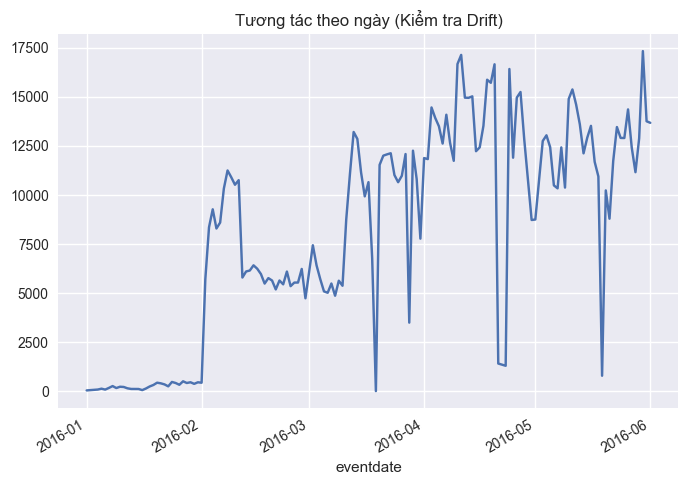

In [61]:
views['eventdate'] = pd.to_datetime(views['eventdate'])
daily_activity = views.groupby('eventdate').size()
daily_activity.plot()
plt.title('Tương tác theo ngày (Kiểm tra Drift)')
plt.show()

### COLD-START

In [62]:
split_date = views['eventdate'].max() - timedelta(days=14)
train = views[views['eventdate'] < split_date]
test = views[views['eventdate'] >= split_date]

new_items = set(test['itemId']) - set(train['itemId'])
cold_start_ratio = len(new_items) / test['itemId'].nunique()
print(f"Tỷ lệ Cold-start Items trong tập Test: {cold_start_ratio * 100:.2f}%")

Tỷ lệ Cold-start Items trong tập Test: 15.85%


### Click-to-Purchase

Tỷ lệ CVR (Click-to-Purchase): 1.60%


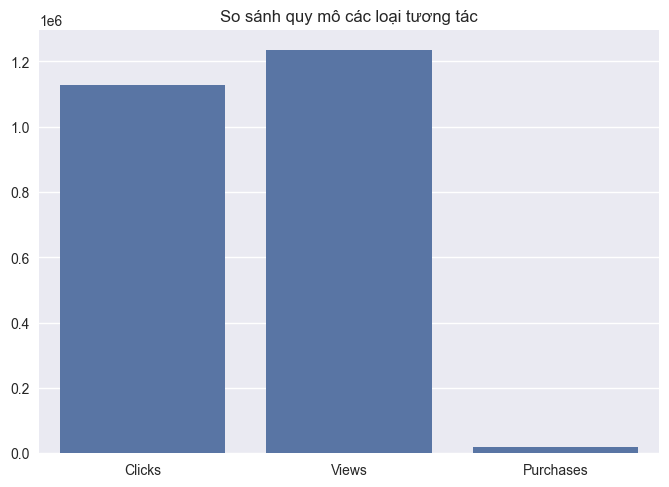

In [36]:
# Kiểm tra tỷ lệ chuyển đổi từ Click sang Purchase
click_to_purchase_rate = (len(purchases) / len(clicks)) * 100
print(f"Tỷ lệ CVR (Click-to-Purchase): {click_to_purchase_rate:.2f}%")

# Vẽ biểu đồ so sánh quy mô 3 loại tương tác
sns.barplot(x=['Clicks', 'Views', 'Purchases'], y=[len(clicks), len(views), len(purchases)])
plt.title('So sánh quy mô các loại tương tác')
plt.show()

## **docs/eda_summary.md**

### Kết luận chính từ dữ liệu:

- Sparsity cực cao: > 99.99%. Bài toán gợi ý dựa trên cộng tác (Collaborative Filtering) truyền thống sẽ không hiệu quả. Cần sử dụng Deep Learning (GNN hoặc RNN).

- Session Length: Median thường là 2-3 hành động. P95 thường < 15.

    - Ngưỡng cắt: Bỏ session length < 2. Cắt session length > 20 (padding/truncating).

- Item Popularity: Hiện tượng đuôi dài (Long-tail) rất mạnh.

    - Rule lọc: Loại bỏ items có tần suất xuất hiện < 5 trên toàn tập dữ liệu để tối ưu kích thước Embedding.

- Time Drift: Dữ liệu có xu hướng tăng giảm theo tuần. Cần split theo thời gian (Time-based split) thay vì random để tránh rò rỉ dữ liệu từ tương lai.

## **docs/problem_definition.md**

### Định nghĩa bài toán

Use Case: Gợi ý sản phẩm tiếp theo (Next-item prediction) cho người dùng ẩn danh (anonymous) dựa trên hành vi trong phiên hiện tại. Trong thực tế thương mại điện tử, có tới hơn 90% người dùng là khách vãng lai hoặc không đăng nhập (anonymous). Do đó, hệ thống không thể dựa vào lịch sử mua sắm dài hạn (long-term history) mà phải bắt lấy "ý định tức thì" (short-term intent) thông qua chuỗi hành động vừa diễn ra trong phiên.

- Quan trọng:

    - Tăng tỷ lệ chuyển đổi (Conversion Rate): Chuyển từ người xem (browsers) thành người mua (buyers).

    - Giảm thiểu sự mệt mỏi khi lựa chọn (Choice Paralysis): Giúp khách hàng tìm thấy thứ họ muốn nhanh hơn trong số hàng nghìn sản phẩm.

    - Tăng giá trị đơn hàng (AOV): Thông qua các kỹ thuật bán chéo (cross-selling) các sản phẩm liên quan ngay trong phiên.

- Input Model: Mô hình hóa dưới dạng chuỗi (sequence) hoặc đồ thị (graph) giúp máy học hiểu được logic chuyển đổi sở thích của người dùng (ví dụ: xem "iPhone" $\rightarrow$ xem "ốp lưng iPhone").

- Output Model: Con số 20 là tiêu chuẩn vàng từ cuộc thi CIKM 2016, mô phỏng số lượng sản phẩm thường xuất hiện trên trang kết quả đầu tiên của một ứng dụng di động hoặc website.

### Success Metrics (Offline):

- Recall@20 (Hit Rate): Trả lời câu hỏi: "Sản phẩm thực tế người dùng đã mua/click có nằm trong danh sách 20 món đồ chúng ta gợi ý hay không?". Đại diện cho khả năng "bao phủ" nhu cầu của khách hàng. Recall càng cao thì xác suất khách hàng chốt đơn càng lớn.

- MRR@20 (Mean Reciprocal Rank): Trả lời câu hỏi: "Sản phẩm đúng nằm ở vị trí thứ mấy?". Nếu sản phẩm đúng nằm ở vị trí số 1, điểm sẽ là 1; nếu nằm ở vị trí số 20, điểm chỉ còn 1/20. Khách hàng thường chỉ chú ý đến 3-5 vị trí đầu tiên. MRR cao giúp giảm thời gian tìm kiếm, tăng trải nghiệm người dùng và trực tiếp thúc đẩy doanh thu do vị trí cao có tỷ lệ nhấp (CTR) cao hơn hẳn.

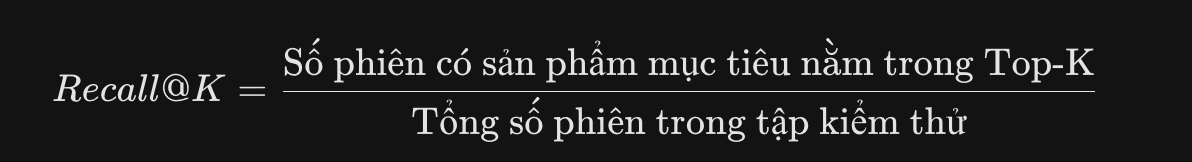

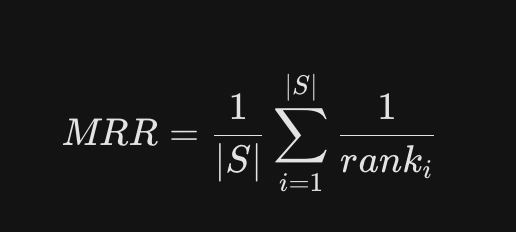

(Trong đó $|S|$ là tổng số phiên, $rank_i$ là vị trí của sản phẩm đúng trong danh sách gợi ý).

### Success Metrics (Service):

- Latency: < 100ms cho mỗi yêu cầu gợi ý. Ngành thương mại điện tử coi 100ms là "ngưỡng snappy". Nếu gợi ý hiện ra chậm hơn, khách hàng sẽ có cảm giác website bị "lag" và dễ dàng rời bỏ phiên. Google và Amazon từng nghiên cứu rằng mỗi 100ms độ trễ tăng thêm có thể làm giảm 1% doanh thu. Tối ưu độ trễ là tối ưu lợi nhuận trực tiếp.

- Throughput: > 500 requests/second. Hệ thống phải chịu tải được hàng nghìn người truy cập cùng lúc, đặc biệt trong các sự kiện Flash Sale hoặc mùa mua sắm cao điểm. Đảm bảo hệ thống không bị sập (downtime) khi lượng truy cập tăng đột biến. Một phút sập hệ thống trong ngày sale lớn có thể gây thiệt hại hàng tỷ đồng.

### Test Linh Tinh

In [77]:
products.head(5)

,itemId,pricelog2,product.name.tokens
0,1,10,"4875,776,56689,18212,18212,4896"
1,69585,6,"7583,18117,41805,41805,2371"
2,90939,6,"604,18117,41805,41805,2371"
3,69586,0,"2936,18117,41805,41805,2371"
4,30029,7,"4668,41805,41805,56652"


In [80]:
clicks.head(20)

,queryId,timeframe,itemId
0,1,16338861,24857
1,46255,16404912,30792
2,46689,3831948,8252
3,46731,16273568,33969
4,46748,4058493,7837
5,46768,11021114,513
6,111737,3098117,86145
7,111737,2911844,11315
8,132852,5320680,607
9,132852,5430077,159430


In [79]:
views

,sessionId,userId,itemId,timeframe,eventdate
0,1,NaN,81766,526309,2016-05-09
1,1,NaN,31331,1031018,2016-05-09
2,1,NaN,32118,243569,2016-05-09
3,1,NaN,9654,75848,2016-05-09
4,1,NaN,32627,1112408,2016-05-09
...,...,...,...,...,...
1235375,600684,NaN,42906,632853,2016-04-14
1235376,600684,NaN,33312,643522,2016-04-14
1235377,600684,NaN,33312,52621,2016-04-14
1235378,600684,NaN,5227,575276,2016-04-14


In [66]:
views[views['sessionId'] == 600661]

,sessionId,userId,itemId,timeframe,eventdate
1235347,600661,NaN,379345,38430,2016-05-15
1235348,600661,NaN,379345,266322,2016-05-15
1235349,600661,NaN,379345,834638,2016-05-15
1235350,600661,NaN,379345,730845,2016-05-15


In [69]:
# Kiểm tra các sản phẩm khác nhau trong cùng 1 session
views[views['sessionId'] == 600661]['itemId'].unique()

array([379345])

In [48]:
purchases

,sessionId,userId,timeframe,eventdate,ordernumber,itemId
0,150,18278.0,17100868,2016-05-06,16421,25911
1,151,NaN,6454547,2016-05-06,16290,175874
2,156,7.0,1721689387,2016-05-27,21173,35324
3,179,NaN,343001,2016-05-09,16924,31233
4,246,34.0,2311046,2016-05-09,16936,34677
...,...,...,...,...,...,...
18020,600131,NaN,3674676,2016-03-18,5675,40804
18021,600250,NaN,4943513,2016-05-21,19629,33777
18022,600432,NaN,205120,2016-04-25,13928,17176
18023,600432,NaN,205120,2016-04-25,13928,13662


In [86]:
purchases[purchases['timeframe'] == 0]

,sessionId,userId,timeframe,eventdate,ordernumber,itemId


In [68]:
queries[queries['sessionId'] == 600661]


,queryId,sessionId,userId,timeframe,duration,eventdate,searchstring.tokens,categoryId,items,is.test
923064,980439,600661,NaN,0,1053,2016-05-15,NaN,965,"7516,30087,7553,37380,30261,59236,48347,261,20...",False


In [49]:
queries

,queryId,sessionId,userId,timeframe,duration,eventdate,searchstring.tokens,categoryId,items,is.test
0,1,1,NaN,16327074,311,2016-05-09,"16655,244087,51531,529597,58153",0,"7518,71,30311,7837,30792,8252,81766,9338,62220...",False
1,2,2,NaN,705527,314,2016-05-09,"528941,529116",0,"70095,15964,8627,134850,32754,100747,74771,314...",False
2,3,3,NaN,0,502,2016-05-09,"133713,16655,138389",0,"59081,51125,9338,9550,32087,62793,2717,10403,3...",True
3,4,4,NaN,0,1092,2016-05-09,"3918,3822,460416,528812,5276,529517,528738",0,"46632,57465,79064,57748,6080,35997,47088,6078,...",False
4,5,5,NaN,102700,266,2016-05-09,"529223,199482",0,"27312,84626,12621,46209,5140,57539,5368,12923,...",False
...,...,...,...,...,...,...,...,...,...,...
923122,980499,600685,NaN,0,407,2016-05-11,NaN,1174,"37197,37877,37878,30493,59914,249161,70728,600...",True
923123,980500,13265,NaN,361805,1203,2016-04-04,NaN,257,"16285,383058,391318,334708,50753,39983,112937,...",False
923124,980501,286379,NaN,953967,3789,2016-04-07,NaN,273,"93417,38387,81656,161236,81657,212080,152555,1...",True
923125,980502,600686,249346.0,0,1581,2016-05-15,NaN,965,"7516,30087,7553,37380,30261,59236,48347,261,20...",True


In [50]:
import pandas as pd

# 1. Định nghĩa hàm kiểm tra chi tiết (đã tối ưu)
def check_variable(df, column_name):
    """Kiểm tra chi tiết một biến trong DataFrame."""
    if column_name not in df.columns:
        return f"Thiếu cột: {column_name}"
    
    null_count = df[column_name].isnull().sum()
    null_pct = (null_count / len(df)) * 100
    n_unique = df[column_name].nunique()
    dtype = df[column_name].dtype
    
    print(f"  - [{column_name}] | Kiểu: {dtype} | Trống: {null_pct:.1f}% | Duy nhất: {n_unique}")

# 2. Định nghĩa cấu trúc dữ liệu dựa trên ảnh bạn gửi
# (Giả sử bạn đã load các biến: products, categories, views, clicks, purchases, queries)
data_structure = {
    "Products": (products, ['itemId', 'pricelog2', 'product.name.tokens']),
    "Categories": (categories, ['itemId', 'categoryID']),
    "Item Views": (views, ['sessionId', 'userId', 'itemId', 'timeframe', 'eventdate']),
    "Clicks": (clicks, ['queryId', 'timeframe', 'itemId']),
    "Purchases": (purchases, ['sessionId', 'userId', 'timeframe', 'eventdate', 'ordernumber', 'itemId']),
    "Queries": (queries, ['queryId', 'sessionId', 'userId', 'timeframe', 'duration', 'eventdate', 'searchstring.tokens', 'categoryID', 'items', 'is.test'])
}

# 3. Vòng lặp kiểm tra toàn bộ
print("========== BÁO CÁO KIỂM TRA TOÀN BỘ DỮ LIỆU ==========\n")

for table_name, (df, columns) in data_structure.items():
    print(f"--- Bảng: {table_name} (Tổng số dòng: {len(df):,}) ---")
    for col in columns:
        check_variable(df, col)
    print("-" * 50 + "\n")

print("========== HOÀN TẤT KIỂM TRA ==========")

========== BÁO CÁO KIỂM TRA TOÀN BỘ DỮ LIỆU ==========

--- Bảng: Products (Tổng số dòng: 184,047) ---
  - [itemId] | Kiểu: int64 | Trống: 0.0% | Duy nhất: 184047
  - [pricelog2] | Kiểu: int64 | Trống: 0.0% | Duy nhất: 13
  - [product.name.tokens] | Kiểu: object | Trống: 0.0% | Duy nhất: 182392
--------------------------------------------------

--- Bảng: Categories (Tổng số dòng: 184,047) ---
  - [itemId] | Kiểu: int64 | Trống: 0.0% | Duy nhất: 184047
--------------------------------------------------

--- Bảng: Item Views (Tổng số dòng: 1,235,380) ---
  - [sessionId] | Kiểu: int64 | Trống: 0.0% | Duy nhất: 310324
  - [userId] | Kiểu: float64 | Trống: 69.8% | Duy nhất: 87934
  - [itemId] | Kiểu: int64 | Trống: 0.0% | Duy nhất: 122993
  - [timeframe] | Kiểu: int64 | Trống: 0.0% | Duy nhất: 644845
  - [eventdate] | Kiểu: object | Trống: 0.0% | Duy nhất: 152
--------------------------------------------------

--- Bảng: Clicks (Tổng số dòng: 1,127,764) ---
  - [queryId] | Kiểu: int64 | Tr